# Baseline — Cross-Generator Biosignature Dataset
MC Dropout CNN adapted from ADC2023 baseline for the crossgen dataset.

- Train: 37,281 TauREx spectra (218 channels, R=100)
- Val: 4,142 TauREx spectra
- Test: 685 POSEIDON spectra (cross-generator generalization)
- Targets: 5 gas VMRs (log10) + planet_radius + temperature

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Reshape, Input, Concatenate, Dropout, Conv1D, Flatten, MaxPooling1D
from tensorflow.keras.models import Model
import pandas as pd
import h5py
import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

## Load data

In [2]:
data_path = 'data/crossgen'

spectra_f = h5py.File(f'{data_path}/spectra.h5', 'r')
labels = pd.read_parquet(f'{data_path}/labels.parquet')

wavelength = spectra_f['wavelength_um'][:]
transit_noisy = spectra_f['transit_depth_noisy'][:]
transit_clean = spectra_f['transit_depth_noiseless'][:]
sigma_ppm = spectra_f['sigma_ppm'][:]
splits = np.array([s.decode() for s in spectra_f['split'][:]])

wl_channels = len(wavelength)
print(f'Spectra: {transit_noisy.shape}')
print(f'Wavelength channels: {wl_channels}')
print(f'Splits: {np.unique(splits, return_counts=True)}')

Spectra: (42108, 218)
Wavelength channels: 218
Splits: (array(['test', 'train', 'val'], dtype='<U5'), array([  685, 37281,  4142]))


## Visualise spectra

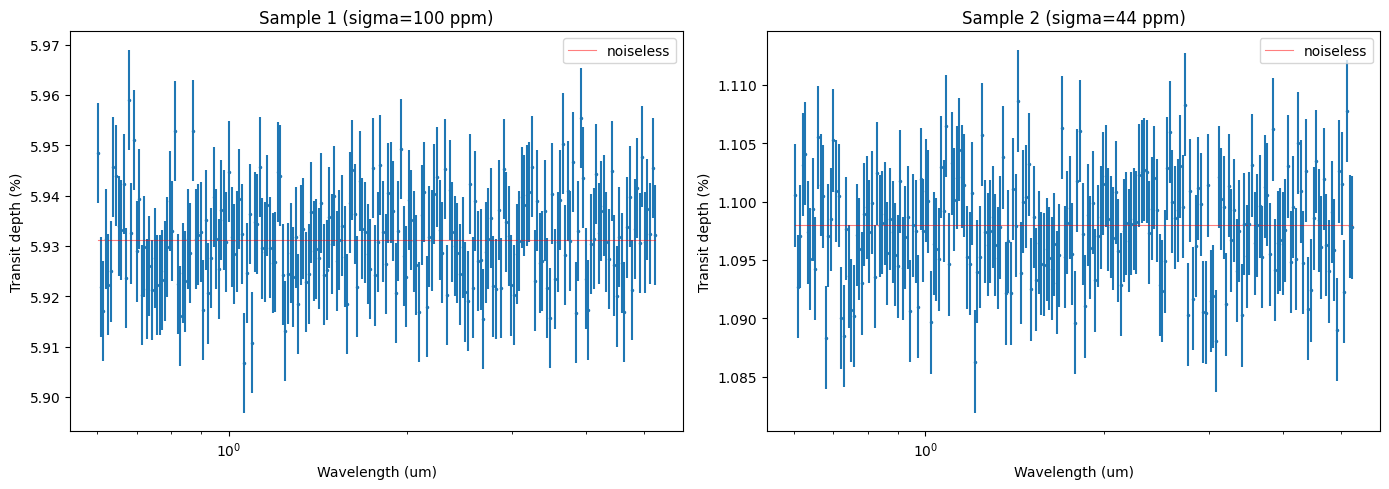

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, ax in enumerate(axes):
    idx = i + 1
    noise_abs = sigma_ppm[idx] * 1e-6
    ax.errorbar(wavelength, transit_noisy[idx] * 100, yerr=noise_abs * 100, fmt='.', markersize=3)
    ax.plot(wavelength, transit_clean[idx] * 100, 'r-', alpha=0.5, lw=0.8, label='noiseless')
    ax.set_xscale('log')
    ax.set_xlabel('Wavelength (um)')
    ax.set_ylabel('Transit depth (%)')
    ax.set_title(f'Sample {idx} (sigma={sigma_ppm[idx]:.0f} ppm)')
    ax.legend()
plt.tight_layout()
plt.show()

## Split data (pre-defined)

In [4]:
train_mask = splits == 'train'
val_mask = splits == 'val'
test_mask = splits == 'test'

target_labels = ['log10_vmr_h2o', 'log10_vmr_co2', 'log10_vmr_co', 'log10_vmr_ch4', 'log10_vmr_nh3']
aux_labels = ['planet_radius_rjup', 'temperature_k']
all_target_labels = aux_labels + target_labels
num_targets = len(all_target_labels)

targets = labels[all_target_labels].values
Rs = labels[['star_radius_rsun']].values

# Split spectra
train_spectra = transit_noisy[train_mask]
val_spectra = transit_noisy[val_mask]
test_spectra = transit_noisy[test_mask]

# Split noise (scalar -> broadcast to channels for augmentation)
train_noise = np.tile(sigma_ppm[train_mask, None] * 1e-6, (1, wl_channels))

# Split targets
train_targets = targets[train_mask]
val_targets = targets[val_mask]
test_targets = targets[test_mask]

# Split auxiliary (star radius)
train_Rs = Rs[train_mask]
val_Rs = Rs[val_mask]
test_Rs = Rs[test_mask]

print(f'Train: {train_spectra.shape[0]}, Val: {val_spectra.shape[0]}, Test: {test_spectra.shape[0]}')
print(f'Targets ({num_targets}): {all_target_labels}')

Train: 37281, Val: 4142, Test: 685
Targets (7): ['planet_radius_rjup', 'temperature_k', 'log10_vmr_h2o', 'log10_vmr_co2', 'log10_vmr_co', 'log10_vmr_ch4', 'log10_vmr_nh3']


## Augment training data with noise

In [5]:
repeat = 5

noise_profile = np.random.normal(0, train_noise, size=(repeat, train_spectra.shape[0], wl_channels))
aug_spectra = (train_spectra[None, ...] + noise_profile).reshape(-1, wl_channels)
aug_Rs = np.tile(train_Rs, (repeat, 1))
aug_targets = np.tile(train_targets, (repeat, 1))

print(f'Augmented: {aug_spectra.shape[0]} samples')

Augmented: 186405 samples


## Standardise

In [6]:
# Spectra stats from training set only
global_mean = np.mean(train_spectra)
global_std = np.std(train_spectra)

std_aug_spectra = (aug_spectra - global_mean) / global_std
std_val_spectra = (val_spectra - global_mean) / global_std
std_test_spectra = (test_spectra - global_mean) / global_std

# Rs stats
mean_Rs = np.mean(train_Rs, axis=0)
std_Rs = np.std(train_Rs, axis=0)

std_aug_Rs = (aug_Rs - mean_Rs) / std_Rs
std_val_Rs = (val_Rs - mean_Rs) / std_Rs
std_test_Rs = (test_Rs - mean_Rs) / std_Rs

# Target stats
targets_mean = np.mean(train_targets, axis=0)
targets_std = np.std(train_targets, axis=0)

std_aug_targets = (aug_targets - targets_mean) / targets_std
std_val_targets = (val_targets - targets_mean) / targets_std

print(f'Spectra global_mean={global_mean:.6f}, global_std={global_std:.6f}')
print(f'Target means: {dict(zip(all_target_labels, targets_mean.round(3)))}')
print(f'Target stds:  {dict(zip(all_target_labels, targets_std.round(3)))}')

Spectra global_mean=0.054780, global_std=0.076749
Target means: {'planet_radius_rjup': np.float64(1.1), 'temperature_k': np.float64(1149.584), 'log10_vmr_h2o': np.float64(-6.981), 'log10_vmr_co2': np.float64(-6.98), 'log10_vmr_co': np.float64(-6.989), 'log10_vmr_ch4': np.float64(-7.009), 'log10_vmr_nh3': np.float64(-7.013)}
Target stds:  {'planet_radius_rjup': np.float64(0.231), 'temperature_k': np.float64(376.971), 'log10_vmr_h2o': np.float64(2.89), 'log10_vmr_co2': np.float64(2.881), 'log10_vmr_co': np.float64(2.887), 'log10_vmr_ch4': np.float64(2.891), 'log10_vmr_nh3': np.float64(2.902)}


## Build and train model

In [7]:
batch_size = 32
lr = 1e-3
epochs = 30
filters = [32, 64, 64]
dropout = 0.1

def build_mc_conv(wl_channels, num_targets, p, filters):
    inp = Input(shape=(wl_channels,))
    aux = Input(shape=(1,))
    x = Reshape((-1, 1))(inp)
    for f in filters:
        x = Conv1D(f, 3, activation='relu')(x)
        x = Conv1D(f, 3, activation='relu')(x)
        x = MaxPooling1D()(x)
    x = Flatten()(x)
    x = Concatenate(axis=-1)([x, aux])
    x = Dense(500, activation='relu')(x)
    x = Dropout(p)(x, training=True)
    x = Dense(100, activation='relu')(x)
    x = Dropout(p)(x, training=True)
    out = Dense(num_targets)(x)
    return Model(inputs=[inp, aux], outputs=out)

model = build_mc_conv(wl_channels, num_targets, dropout, filters)
model.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 218)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 218, 1)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 216, 32)   │        128 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 214, 32)   │      3,104 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 107, 32)   │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 105, 64)   │      6,208 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 103, 64)   │     12,352 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 51, 64)    │          0 │ conv1d_3[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 49, 64)    │     12,352 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 47, 64)    │     12,352 │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_2     │ (None, 23, 64)    │          0 │ conv1d_5[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1472)      │          0 │ max_pooling1d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1473)      │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 500)       │    737,000 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 500)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 100)       │     50,100 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 100)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 7)         │        707 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 834,303 (3.18 MB)

 Trainable params: 834,303 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    [std_aug_spectra, std_aug_Rs],
    std_aug_targets,
    validation_data=([std_val_spectra, std_val_Rs], std_val_targets),
    batch_size=batch_size,
    epochs=epochs,
    shuffle=True,
)

Epoch 1/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.8446 - val_loss: 0.7975
Epoch 2/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.6991 - val_loss: 0.5186
Epoch 3/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 32s 5ms/step - loss: 0.4159 - val_loss: 0.3236
Epoch 4/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - loss: 0.3470 - val_loss: 0.2821
Epoch 5/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - loss: 0.3228 - val_loss: 0.2673
Epoch 6/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.3125 - val_loss: 0.2797
Epoch 7/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 40s 7ms/step - loss: 0.3051 - val_loss: 0.2747
Epoch 8/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - loss: 0.3011 - val_loss: 0.2614
Epoch 9/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 44s 8ms/step - loss: 0.2966 - val_loss: 0.2438
Epoch 10/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 47s 8ms/step - loss: 0.2925 - val_loss: 0.2444
Epoch 11/30
5826/5826 ━━━━━━━━━━━━━━━━━━━━ 59s 10ms/step - loss: 0.2902 - val_loss: 0.2625
Epoch 12/30
5826/5

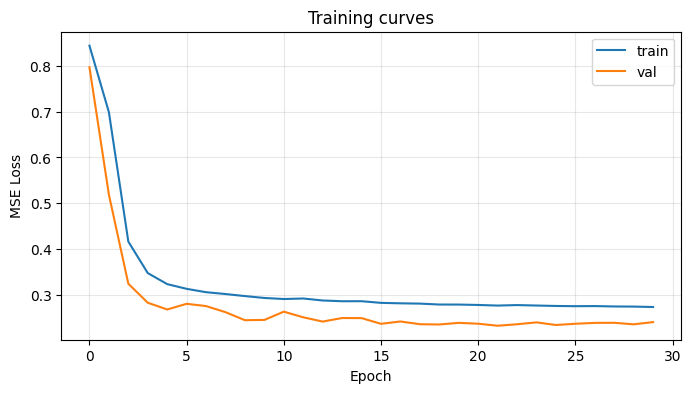

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training curves')
plt.grid(True, alpha=0.3)
plt.show()

## Evaluate on validation set (MC Dropout)

In [10]:
N_mc = 100  # fewer samples for quick val evaluation

y_val_dist = np.zeros((N_mc, len(std_val_spectra), num_targets))
for i in tqdm(range(N_mc)):
    y_val_dist[i] = model([std_val_spectra, std_val_Rs], training=True)

# Inverse standardise
y_val_pred = y_val_dist * targets_std[None, None, :] + targets_mean[None, None, :]
y_val_mean = y_val_pred.mean(axis=0)  # (N_val, 7)
y_val_std = y_val_pred.std(axis=0)

# RMSE per target
val_rmse = np.sqrt(np.mean((y_val_mean - val_targets) ** 2, axis=0))
print('Validation RMSE per target:')
for name, rmse in zip(all_target_labels, val_rmse):
    print(f'  {name}: {rmse:.4f}')

100%|██████████| 100/100 [00:17<00:00,  5.78it/s]

Validation RMSE per target:
  planet_radius_rjup: 0.0489
  temperature_k: 136.7035
  log10_vmr_h2o: 1.6341
  log10_vmr_co2: 1.1698
  log10_vmr_co: 2.2362
  log10_vmr_ch4: 1.2276
  log10_vmr_nh3: 1.3956


## Evaluate on POSEIDON test set (cross-generator)

In [21]:
N_mc_test = 100

y_test_dist = np.zeros((N_mc_test, len(std_test_spectra), num_targets))
for i in tqdm(range(N_mc_test)):
    y_test_dist[i] = model([std_test_spectra, std_test_Rs], training=True)

y_test_pred = y_test_dist * targets_std[None, None, :] + targets_mean[None, None, :]
y_test_mean = y_test_pred.mean(axis=0)
y_test_std_pred = y_test_pred.std(axis=0)

test_rmse = np.sqrt(np.mean((y_test_mean - test_targets) ** 2, axis=0))
print('Test RMSE per target (POSEIDON, cross-generator):')
for name, rmse in zip(all_target_labels, test_rmse):
    print(f'  {name}: {rmse:.4f}')

100%|██████████| 100/100 [00:02<00:00, 37.77it/s]

Test RMSE per target (POSEIDON, cross-generator):
  planet_radius_rjup: 0.0997
  temperature_k: 515.7788
  log10_vmr_h2o: 3.1275
  log10_vmr_co2: 3.6915
  log10_vmr_co: 3.2584
  log10_vmr_ch4: 3.3517
  log10_vmr_nh3: 3.1749


## Biosignature binary accuracy

In [22]:
presence_cols = ['present_h2o', 'present_co2', 'present_co', 'present_ch4', 'present_nh3']
gas_targets = target_labels  # the 5 gas columns
threshold = -8.0  # log10 VMR boundary: absent=[-12,-8], present=[-8,-2]

test_presence_gt = labels[test_mask][presence_cols].values

# Predict presence from mean VMR prediction
gas_pred_mean = y_test_mean[:, 2:]  # skip radius & temp
pred_present = (gas_pred_mean > threshold).astype(int)

print('Binary biosignature accuracy (test):')
for i, col in enumerate(presence_cols):
    acc = np.mean(pred_present[:, i] == test_presence_gt[:, i])
    print(f'  {col}: {acc:.4f}')

Binary biosignature accuracy (test):
  present_h2o: 0.4861
  present_co2: 0.4321
  present_co: 0.4891
  present_ch4: 0.4686
  present_nh3: 0.5022


## Summary

In [23]:
print('='*60)
print('BASELINE RESULTS')
print('='*60)
print(f'\nModel: MC Dropout CNN, {model.count_params()} params')
print(f'Training: {train_spectra.shape[0]} samples x{repeat} aug, {epochs} epochs')
print(f'\nVal RMSE (TauREx):')
for name, rmse in zip(all_target_labels, val_rmse):
    print(f'  {name}: {rmse:.4f}')
print(f'\nTest RMSE (POSEIDON, cross-generator):')
for name, rmse in zip(all_target_labels, test_rmse):
    print(f'  {name}: {rmse:.4f}')

BASELINE RESULTS

Model: MC Dropout CNN, 834303 params
Training: 37281 samples x5 aug, 30 epochs

Val RMSE (TauREx):
  planet_radius_rjup: 0.0489
  temperature_k: 136.7035
  log10_vmr_h2o: 1.6341
  log10_vmr_co2: 1.1698
  log10_vmr_co: 2.2362
  log10_vmr_ch4: 1.2276
  log10_vmr_nh3: 1.3956

Test RMSE (POSEIDON, cross-generator):
  planet_radius_rjup: 0.0997
  temperature_k: 515.7788
  log10_vmr_h2o: 3.1275
  log10_vmr_co2: 3.6915
  log10_vmr_co: 3.2584
  log10_vmr_ch4: 3.3517
  log10_vmr_nh3: 3.1749


--- VALIDATION (TauREx) ---

=============== BASELINE BENCHMARK RESULTS ===============
CrossGen TauREx Validation (4,142 samples)

log10_vmr_h2o      | Acc (<=5%):  21.34% | R2:  0.6746 | RMSE: 1.6341
log10_vmr_co2      | Acc (<=5%):  29.60% | R2:  0.8366 | RMSE: 1.1698
log10_vmr_co       | Acc (<=5%):  11.97% | R2:  0.4111 | RMSE: 2.2362
log10_vmr_ch4      | Acc (<=5%):  28.46% | R2:  0.8149 | RMSE: 1.2276
log10_vmr_nh3      | Acc (<=5%):  25.57% | R2:  0.7682 | RMSE: 1.3956


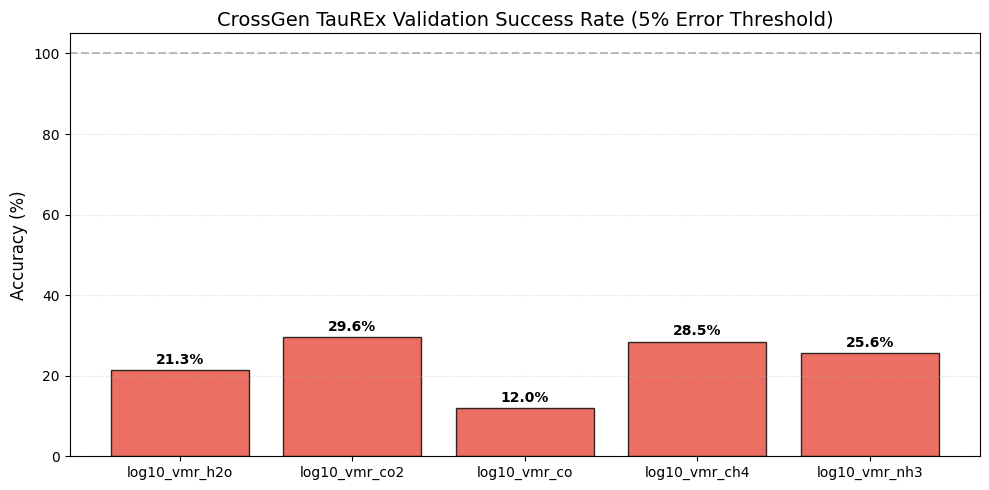

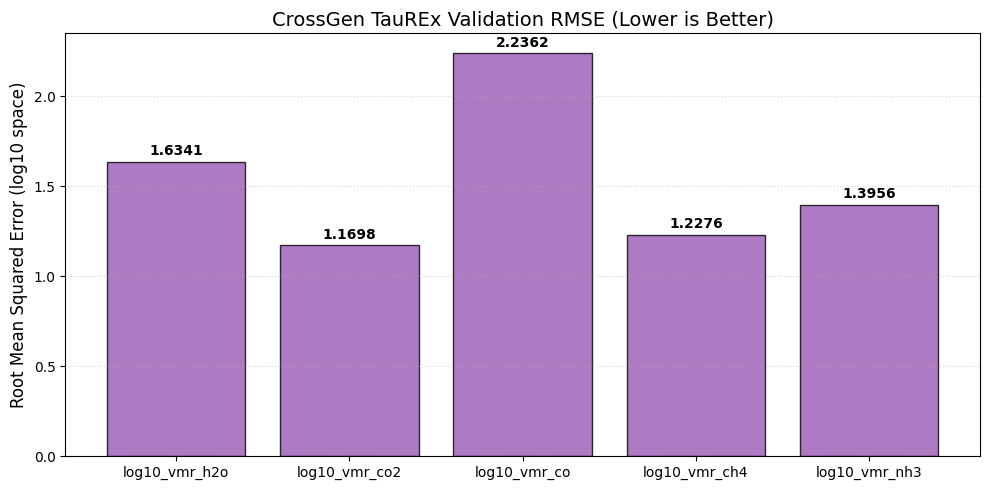



--- TEST (POSEIDON, cross-generator) ---

=============== BASELINE BENCHMARK RESULTS ===============
CrossGen POSEIDON Test (685 samples)

log10_vmr_h2o      | Acc (<=5%):   8.03% | R2: -0.1857 | RMSE: 3.1275
log10_vmr_co2      | Acc (<=5%):   8.76% | R2: -0.5503 | RMSE: 3.6915
log10_vmr_co       | Acc (<=5%):   9.34% | R2: -0.3138 | RMSE: 3.2584
log10_vmr_ch4      | Acc (<=5%):   8.76% | R2: -0.2993 | RMSE: 3.3517
log10_vmr_nh3      | Acc (<=5%):  10.22% | R2: -0.2484 | RMSE: 3.1749


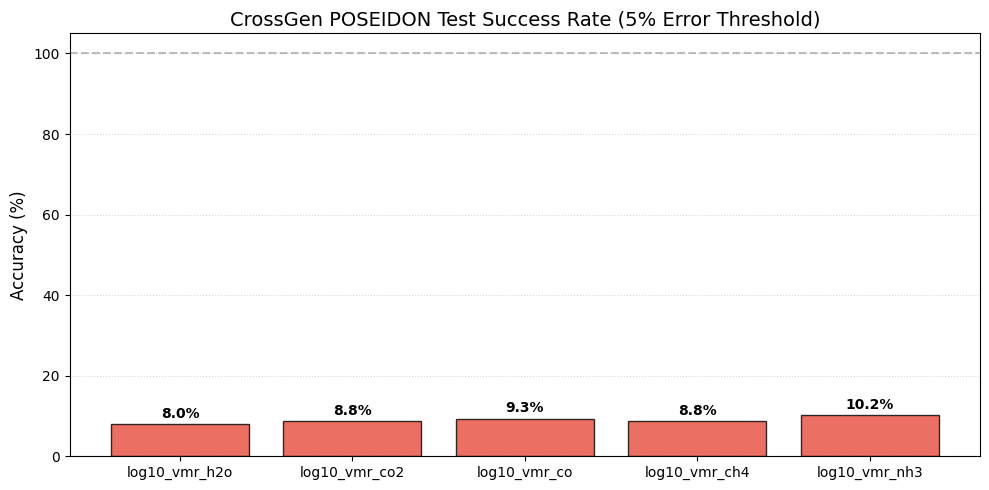

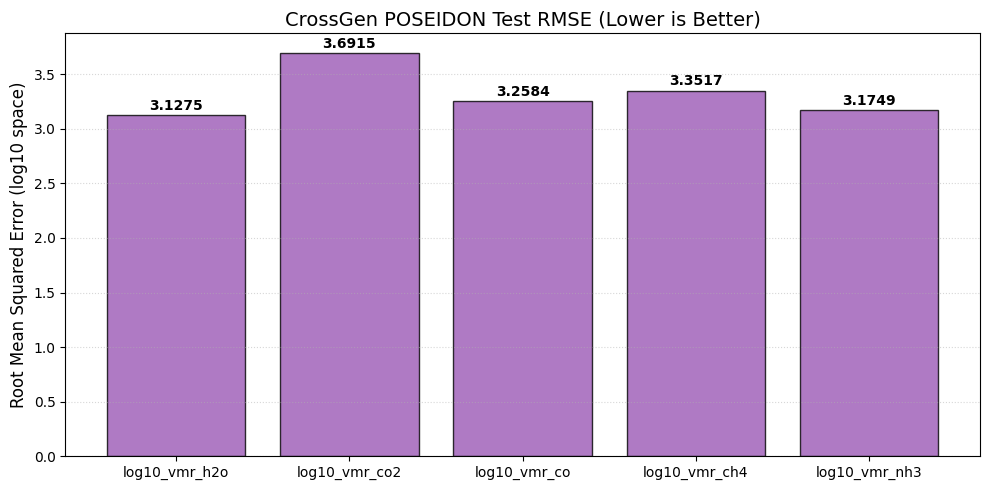

In [24]:
from sklearn.metrics import r2_score

gas_idx = slice(2, None)
gas_names = target_labels

def benchmark(y_true, y_mean, set_name, n_samples):
    gas_true = y_true[:, gas_idx]
    gas_pred = y_mean[:, gas_idx]

    rmses, r2s, accs = [], [], []
    for i in range(len(gas_names)):
        t, p = gas_true[:, i], gas_pred[:, i]
        rmses.append(np.sqrt(np.mean((p - t) ** 2)))
        r2s.append(r2_score(t, p))
        rel_err = np.abs((p - t) / t)
        accs.append(np.mean(rel_err <= 0.05) * 100)

    print(f'{"=" * 15} BASELINE BENCHMARK RESULTS {"=" * 15}')
    print(f'{set_name} ({n_samples:,} samples)\n')
    for name, acc, r2, rmse in zip(gas_names, accs, r2s, rmses):
        print(f'{name:<18} | Acc (<=5%): {acc:6.2f}% | R2: {r2:7.4f} | RMSE: {rmse:.4f}')

    # --- Accuracy bar chart ---
    colors_acc = ['#e74c3c' if a < 50 else '#3498db' for a in accs]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(gas_names, accs, color=colors_acc, edgecolor='black', alpha=0.8)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title(f'{set_name} Success Rate (5% Error Threshold)', fontsize=14)
    ax.set_ylim(0, 105)
    ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.8,
                f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- RMSE bar chart ---
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(gas_names, rmses, color='#9b59b6', edgecolor='black', alpha=0.8)
    ax.set_ylabel('Root Mean Squared Error (log10 space)', fontsize=12)
    ax.set_title(f'{set_name} RMSE (Lower is Better)', fontsize=14)
    ax.grid(axis='y', linestyle=':', alpha=0.5)
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, yval + 0.02,
                f'{yval:.4f}', ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return accs, r2s, rmses

print('--- VALIDATION (TauREx) ---\n')
val_accs, val_r2s, val_rmses = benchmark(val_targets, y_val_mean, 'CrossGen TauREx Validation', len(val_targets))
print('\n\n--- TEST (POSEIDON, cross-generator) ---\n')
test_accs, test_r2s, test_rmses = benchmark(test_targets, y_test_mean, 'CrossGen POSEIDON Test', len(test_targets))
